# 8.2.1 梯度下降的步长与条件数

## 学习目标与先修知识

推导二次目标上的步长范围，解释振荡、病态与变量缩放。

先修：8.1的二次目标、特征方向及严格凸最小点。 [本篇学习次序](../README.md)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

同一个拟合目标，用很小的步长几乎不动，用很大的步长却越走越远。怎样在运行前判断步长，怎样解释狭长等高线中的“来回摆动”？

In [1]:
import math
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]
BLUE, PINK, GREEN, GRAY = "#327cac", "#c35178", "#338b7c", "#68768a"

## 初步实验

In [2]:
for step in [.1,1.,1.1]:
    values=[1.]
    for _ in range(6):values.append((1-2*step)*values[-1])
    print('步长',step,'标量误差',np.round(values,3))

步长 0.1 标量误差 [1.    0.8   0.64  0.512 0.41  0.328 0.262]
步长 1.0 标量误差 [ 1. -1.  1. -1.  1. -1.  1.]
步长 1.1 标量误差 [ 1.    -1.2    1.44  -1.728  2.074 -2.488  2.986]


## 模型假设

首先固定正定（positive definite）对称H，目标为xᵀHx/2−bᵀx。变量已无量纲（dimensionless）化，步长也在该坐标中定义。无随机梯度（gradient）、无约束投影（projection）。给出的严格步长范围保证任意初始误差收敛；若某个特征方向初始误差恰好为零，单条轨迹（trajectory）可能掩盖该方向的失稳。

## 数学解释与推导

### 从局部下降到离散递推

梯度下降取 $x_{k+1}=x_k-\eta(Hx_k-b)$。减去 $Hx^*=b$，令 $e_k=x_k-x^*$，得到
$$e_{k+1}=(I-\eta H)e_k.$$
在H的第j个单位特征方向上，标量误差按 $z_{k+1,j}=(1-\eta\lambda_j)z_{k,j}$ 更新。复用第2篇的差分条件：衰减看绝对值，不能只检查小于1。因此
$$|1-\eta\lambda_j|<1\ \text{对所有j成立}\iff 0<\eta<\frac{2}{\lambda_{\max}}.$$
等号处有因子−1，只振荡而不衰减；大于上界会增长。对正定二次目标，这个范围也使每个非最优点的目标严格下降。

### 条件数与变量尺度

令 $\mu=\lambda_{\min}>0,L=\lambda_{\max}$，谱条件数（condition number） $\kappa=L/\mu$。当L很大而μ很小，步长受快方向限制，慢方向因子却接近1。理论上兼顾两端因子的常步长是 $2/(L+\mu)$，收缩因子为 $(\kappa-1)/(\kappa+1)$；这里已经知道曲率才能这样选择。

小梯度也必须结合μ：$\|e\|\le\|\nabla f\|/\mu$。平坦方向中，梯度小不必然意味着坐标误差小。

若写x=Dz，目标矩阵（matrix）变为 $D^THD$，线性项变为 $D^Tb$。在z中做普通梯度下降映回x，等价于使用 $DD^T$ 改变方向度量。坐标变换保持问题，算法轨迹却可以变化；必须同时变换目标和初值（initial condition）。


## 核心实现

按上述推导逐步计算；保留明确的更新预算与返回标签。

In [3]:
def quadratic(matrix, linear, point):
    """f(x)=xᵀHx/2-bᵀx; inputs use the same dimensionless coordinates."""
    gradient = [sum(a*x for a, x in zip(row, point))-b
                for row, b in zip(matrix, linear)]
    value = sum(x*(g-b) for x, g, b in zip(point, gradient, linear))/2
    return value, gradient, [list(row) for row in matrix]


def gradient_descent(matrix, linear, initial, step, max_steps, tolerance):
    point = list(initial)
    history = [point[:]]
    for iteration in range(max_steps+1):
        value, gradient, _ = quadratic(matrix, linear, point)
        residual = math.hypot(*gradient)
        if not math.isfinite(residual) or not math.isfinite(value):
            return history, None, 'nonfinite'
        if residual <= tolerance:
            return history, residual, 'converged'
        if iteration == max_steps:
            return history, residual, 'max_steps'
        point = [x-step*g for x, g in zip(point, gradient)]
        history.append(point[:])

## 对照实验

步长 0.05 末端梯度 0.21464 状态 max_steps
步长 0.18 末端梯度 0.01265 状态 max_steps
步长 0.2 末端梯度 10.0 状态 max_steps
步长 0.22 末端梯度 2373.76314 状态 max_steps


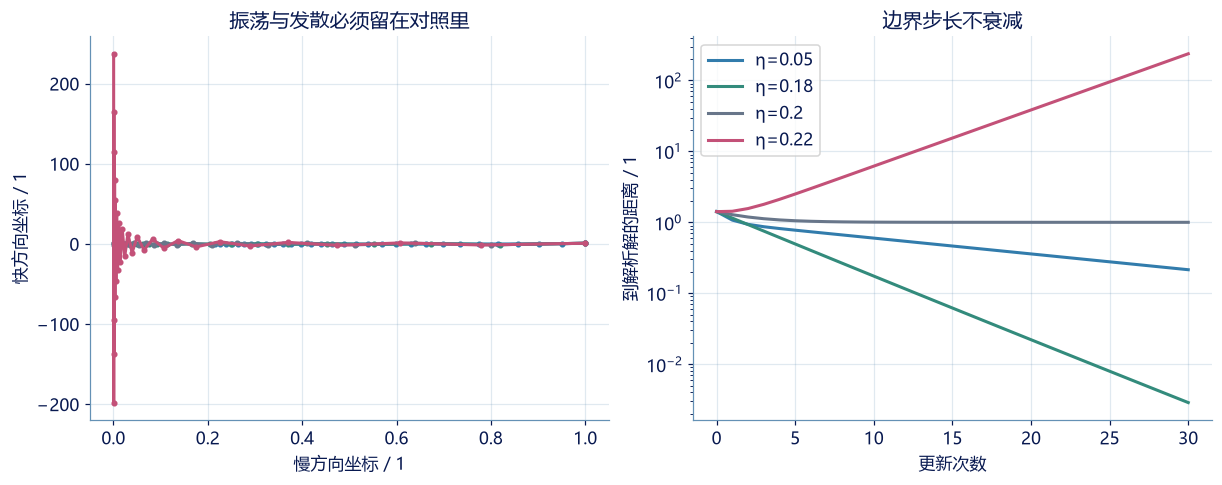

In [4]:
H=np.diag([1.,10.]);b=np.zeros(2);initial=[1.,1.]
fig,axes=plt.subplots(1,2,figsize=(11,4.3))
for step,color in [(.05,BLUE),(.18,GREEN),(.2,GRAY),(.22,PINK)]:
    history,residual,status=gradient_descent(H,b,initial,step,30,1e-10)
    history=np.array(history)
    axes[0].plot(history[:,0],history[:,1],'.-',color=color,label=f'η={step}')
    axes[1].semilogy(np.maximum(np.linalg.norm(history,axis=1),1e-15),color=color,label=f'η={step}')
    print('步长',step,'末端梯度',round(residual,5),'状态',status)
axes[0].set(xlabel='慢方向坐标 / 1',ylabel='快方向坐标 / 1',title='振荡与发散必须留在对照里')
axes[1].set(xlabel='更新次数',ylabel='到解析解的距离 / 1',title='边界步长不衰减');axes[1].legend();plt.show()

### 独立核验与边界

In [5]:
step=.18;history,_,_=gradient_descent(H,b,initial,step,20,0.)
exact=np.array([np.linalg.matrix_power(np.eye(2)-step*H,k)@initial for k in range(21)])
np.testing.assert_allclose(history,exact,atol=1e-12)
H2=np.diag([1.,100.]);D=np.diag([1.,.1]);z0=np.linalg.solve(D,initial)
z_history,_,_=gradient_descent(D.T@H2@D,[0,0],z0,1.,2,1e-12)
np.testing.assert_allclose(D@z_history[-1],[0,0],atol=1e-12)
assert gradient_descent(H,b,[0,0],.1,0,1e-9)[2]=='converged'
assert gradient_descent(H,b,initial,.1,0,1e-9)[2]=='max_steps'
print('特征递推、尺度变换和零预算检查通过。')

特征递推、尺度变换和零预算检查通过。


## 结果解释

η=.2的快方向在两个符号之间往返，距离不会降到零；η=.22则增长。这两条轨迹展示了步长到达或超过稳定边界后的行为。缩放实验改变了算法看到的曲率；有约束时，还要一并变换约束，而非只改图的坐标标签。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：实现有预算的梯度下降

用固定步长最小化严格凸二次目标，同时如实报告停止原因。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    linear: list[float],
    initial: list[float],
    step: float,
    max_steps: int,
    tolerance: float,
) -> tuple[list[list[float]], float | None, str]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | 无量纲 |
| `linear` | `list[float]` | 线性项 b，符号按目标中的减号。 | 无量纲 |
| `initial` | `list[float]` | 初始点x₀，包含在轨迹（trajectory）首行。 | 无量纲 |
| `step` | `float` | 固定步长η。 | 无量纲 |
| `max_steps` | `int` | 最多执行的更新次数。 | 次 |
| `tolerance` | `float` | 梯度（gradient）二范数（norm）停止阈值。 | 无量纲 |

**返回值**

按以下顺序返回元组：(trajectory, residual, status)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `trajectory` | `list[list[float]]` | 初值（initial condition）及每次更新后的点。 | 无量纲 |
| `residual` | <code>float &#124; None</code> | 最后梯度二范数；非有限计算时为None。 | 无量纲 |
| `status` | `str` | converged、max_steps或nonfinite。 | 不适用 |

**计算规则**

每次先检查当前梯度二范数≤tolerance，再检查是否已更新max_steps次；否则x←x−step(Hx−b)。初值已达标即返回一行轨迹。

**约束与边界**

- 二维正定（positive definite）H，元素≤20；0<step≤1；0≤max_steps≤30；tolerance>0；测试均保持有限数值。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | [[2.0, 0.0], [0.0, 4.0]] | 无量纲 |
| linear | 线性项 b，符号按目标中的减号。 | [0.0, 0.0] | 无量纲 |
| initial | 初始点x₀，包含在轨迹（trajectory）首行。 | [1.0, 1.0] | 无量纲 |
| step | 固定步长η。 | 0.25 | 无量纲 |
| max_steps | 最多执行的更新次数。 | 3 | 次 |
| tolerance | 梯度（gradient）二范数（norm）停止阈值。 | 0.01 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[2.0, 0.0], [0.0, 4.0]]
linear = [0.0, 0.0]
initial = [1.0, 1.0]
step = 0.25
max_steps = 3
tolerance = 0.01

result = solve(matrix, linear, initial, step, max_steps, tolerance)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| trajectory | 初值（initial condition）及每次更新后的点。 | [[1.0, 1.0], [0.5, 0.0], [0.25, 0.0], [0.125, 0.0]] | 无量纲 |
| residual | 最后梯度二范数；非有限计算时为None。 | 0.25 | 无量纲 |
| status | converged、max_steps或nonfinite。 | max_steps | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[1.0, 1.0],
                    [0.5, 0.0],
                    [0.25, 0.0],
                    [0.125, 0.0]],
                   0.25,
                   'max_steps')
```

**样例解释**

三步后为[0.125,0]，梯度范数0.25仍大于0.01，应报告max_steps。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：实现有预算的梯度下降](http://127.0.0.1:8000/chapters/08-02-%E6%A2%AF%E5%BA%A6%E3%80%81%E6%9B%B2%E7%8E%87%E4%B8%8E%E8%BF%AD%E4%BB%A3%E7%AE%97%E6%B3%95/practice/?question=p08-gradient-steps)

### 第 2 题 · 单项选择题：步长上界要严格

H=diag(1,10)。要使任意初值（initial condition）的误差都收敛到零，固定正步长η应满足什么？

- **A.** 0<η<0.2。
- **B.** 0<η≤0.2。
- **C.** 0<η<2。
- **D.** η越大越快且总会收敛。

[作答：步长上界要严格](http://127.0.0.1:8000/chapters/08-02-%E6%A2%AF%E5%BA%A6%E3%80%81%E6%9B%B2%E7%8E%87%E4%B8%8E%E8%BF%AD%E4%BB%A3%E7%AE%97%E6%B3%95/practice/?question=p08-step-limit)

### 第 3 题 · 多项选择题：两种慢的原因

同为正定（positive definite）二次目标，H₁=I，H₂=diag(1,100)。使用η=.01，第二个目标可能慢在哪里？

- **A.** 较小曲率方向误差每步只乘0.99。
- **B.** 大曲率方向决定不失稳所需的步长上界。
- **C.** 条件数（condition number）只反映最大特征值（eigenvalue）的绝对大小。
- **D.** 等比例放大H与b并相应缩小η，轨迹（trajectory）可保持一致。

[作答：两种慢的原因](http://127.0.0.1:8000/chapters/08-02-%E6%A2%AF%E5%BA%A6%E3%80%81%E6%9B%B2%E7%8E%87%E4%B8%8E%E8%BF%AD%E4%BB%A3%E7%AE%97%E6%B3%95/practice/?question=p08-conditioning)

### 第 4 题 · 多项选择题：小梯度能说明多近

H=diag(0.001,1)，b=0，x=[1,0]。梯度（gradient）范数（norm）为0.001。哪些解释正确？

- **A.** 离最小点的距离仍为1。
- **B.** 小梯度必说明每个坐标误差都很小。
- **C.** 若已知最小特征值（eigenvalue）μ>0，可用‖x−x*‖≤‖g‖/μ。
- **D.** 比较不同单位的梯度阈值时需要说明尺度。

[作答：小梯度能说明多近](http://127.0.0.1:8000/chapters/08-02-%E6%A2%AF%E5%BA%A6%E3%80%81%E6%9B%B2%E7%8E%87%E4%B8%8E%E8%BF%AD%E4%BB%A3%E7%AE%97%E6%B3%95/practice/?question=p08-small-gradient)

### 延伸阅读

[Boyd 与 Vandenberghe：《Convex Optimization》](https://web.stanford.edu/~boyd/cvxbook/)，第9章：梯度法、收敛与条件数。

[概念探索与交互](http://127.0.0.1:8000/chapters/08-02-梯度、曲率与迭代算法/explore/) · [本篇目录](../README.md)